In [1]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [2]:
import numpy as np
import pylab as plt
import networkx as nx
import SimpleITK as sitk
from skimage.data import binary_blobs
from skimage.measure import marching_cubes
from graphomics import SkeletonizeImageFilter
from graphomics import GraphThicknessImageFilter

# Graph Extraction

Demo of the `GraphThicknessImageFilter` applied for the extraction of the volumetric graph.

In this demo we will see how we can manage the information obtained by the filter for the extraction and manipulation of the corresponding graph.
For the definition of the graph we will use the `networkx` library.
Analogous results can be obtained using a different library.

Since we are not interested in the analysis of a particular volume, we will use as case study a random 3D blob generated using the `skimage` library. 

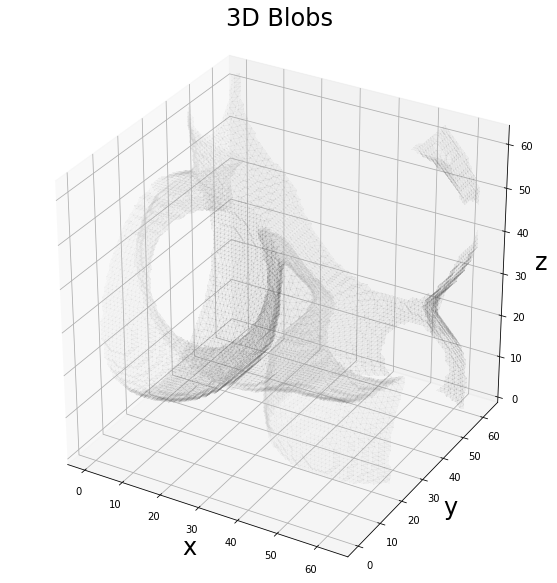

In [3]:
# Generate 3D random blobs
volume = binary_blobs(length=64, 
                      blob_size_fraction=.5, 
                      volume_fraction=.7, 
                      seed=42,
                      n_dim=3
                     )

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(volume, 0)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blobs', fontsize=24)

The generated volume describes an irregular shape in the 3D space which can mimic an arbitrary realistic volume.
The first step of the analysis involves the definition and extraction of the 3D skeleton using the Lee algorithm.
In this case we can check that the number of connected components which define the 3D volume is equal to the number of connected components resulting by the skeletonization algorithm.

In [4]:
from scipy.ndimage import label as connected_components

# define a structural elements as a 3x3x3 cube
cube = np.ones(shape=(3, 3, 3), dtype=bool)

# extract the connected components in the 3D volume
lbl_vol, n_vol = connected_components(volume != 0, structure=cube)
print('Volume connected components: {:d}'.format(n_vol))

# convert the volume to SimpleITK fmt
sitk_volume = sitk.GetImageFromArray(np.uint8(volume))

# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()
# apply the skleletonization algorithm
skeletonizer.Execute(sitk_volume)
skeleton = skeletonizer.GetSkeletonImage()
# retro-transform the output to Numpy
np_skeleton = sitk.GetArrayFromImage(skeleton)

# extract the connected components in the 3D skeleton
lbl_sk, n_sk = connected_components(np_skeleton != 0, structure=cube)
print('Skeleton connected components: {:d}'.format(n_sk))

Volume connected components: 1
Skeleton connected components: 1


The generated 3D volume includes only 1 connected components according to a 26-connectivity.
As expected, the skeleton obtained by the Lee algorithm preserves the number of connected components, providing a skeleton given by a single connected component.

We can visualize the resulting skeleton as a series of points in the 3D space, interal to the 3D volume.

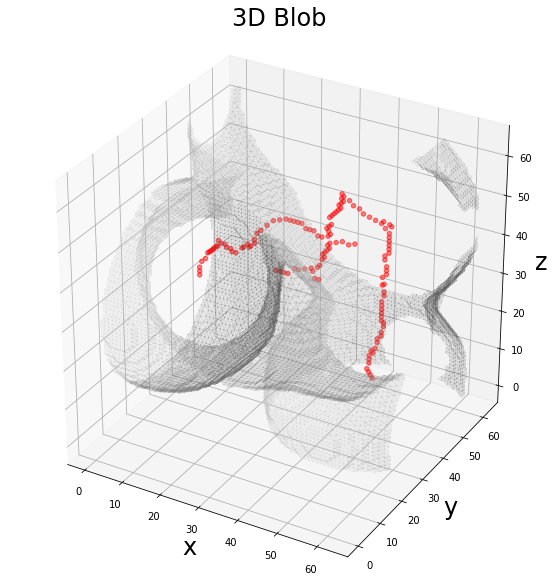

In [5]:
# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blob', fontsize=24)

Now we can apply the graph filter to the obtained skeleton "volume", extracting the information about the node positions and edge-connections.

In [6]:
# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter(surface_min_points=8,
                                      # minimum number of points for the node identification
                                      remove_surface=True
                                      # remove the skeleton surfaces
                                      )

# execute the filter
extractor.Execute(skeleton)

# get the returning values
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()

print('Number of nodes found: {:d}'.format(len(nodes)))
print('Number of edges found: {:d}'.format(len(edges)))

Number of nodes found: 13
Number of edges found: 12


As expected the resulting graph is quite sparse and close to a chain, indeed the number of nodes is close to the number of edges.

A good way to verify the correctness of the graph is the plotting of this information on the same plot.

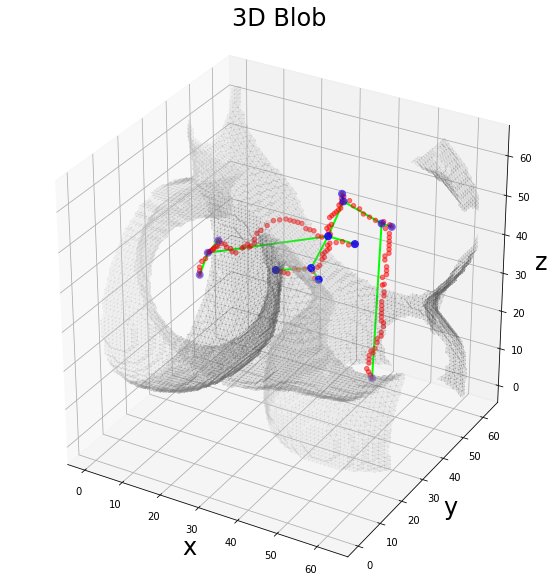

In [7]:
# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)
    
# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=50)
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blob', fontsize=24)

Since we have the full list of nodes and edges, we can define a graph using these two arrays and the `networkx` library.

We have no information about the direction of the edges (since it is not defined in the 3D volume shape), therefore we will use a simple `nx.Graph` for the storing of the information.

In [8]:
# define the graph
graph = nx.Graph()
# add the list of nodes to the empty graph
graph.add_nodes_from(nodes)
# add the list of edges to the graph
graph.add_edges_from(edges)

print('Number of nodes: {:d}'.format(nx.number_of_nodes(graph)))
print('Number of edges: {:d}'.format(nx.number_of_edges(graph)))

Number of nodes: 13
Number of edges: 12


Now that we have the filter information stored as a mathematical graph, we can try to analyze it using graph-theory algorithms.
For example, we can check that the number of connected components found by the application of the filter is consistent with the number of components of the skeleton, i.e. there must by only 1 connected component.

In [9]:
for i, comp in enumerate(nx.connected_components(graph)):
    print('Number of nodes belonging to the connected component {:d}: {:d}'.format(i, len(comp)))

Number of nodes belonging to the connected component 0: 13


As expected, the application of the filter preserves all the information.

A second standard metric for the evaluation of a graph is given by the degree centrality measure.
Since by the visualization of the skeleton we can easily notice how the obtained graph is close to a chain, we can re-view the plot weighing the nodes according to their degree.

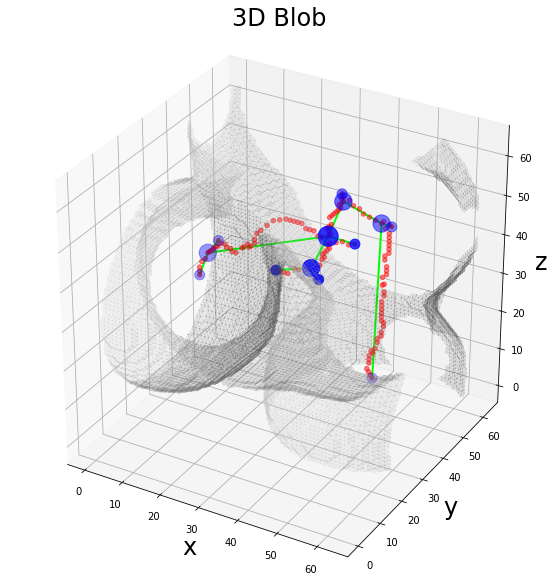

In [10]:
degree = nx.degree(graph)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=20, alpha=0.5)

# define the size of the nodes as 100x the degree value
degree_size = [degree[n]*100 for n in nodes]

# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=degree_size)
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blob', fontsize=24)

As expected, the bifurcation points are stored as the nodes of the graph with the higher centrality, especially in comparison with the tails of the skeleton, i.e. the pendant (degree == 1) nodes.

Up to now, we have worked with a topological graph, i.e. an unweighted graph obtained by the morphological description of the skeleton bifurcations.
However, the application of the filter provides further information that can be used for association of weights to the graph.
For example, we can weight the edges of our graph according to the number of points which describe the connection between two nodes.

**Note:** the number of points can be estimated as simple Euclidean distance between the node coordinates **or** as the number of points belonging to the skeleton path which connects the two nodes.
In the first case is sufficient to apply a function to the node coordinates extracted up to now and weight the edges accordingly.
In the second case (our topic now!) we need to extract the information about the paths from the labeled skeleton volume.

The graph filter, indeed, provides two methods, `GetEdgeLUT` and `GetEdgeMap` respectively, which allow to extract the information from the analyzed skeleton.
In detail:

* `GetEdgeLUT`: returns the lookup table of the edge labels for the edge map.
* `GetEdgeMap`: returns the edge-map of the volumes. 
    The edge map stores the edge paths as disjoint lines in the original volume. 
    The connected components of the edge-map are the edges of the graph found by the filter.
    
In our case the `edgeLUT` provides a dictionary of values corresponding to each edge found in the skeleton volume, while the `edgeMap` gives the corresponding labeled volume.
In this way from the `edgeLUT` we can extract the labels, search it in the `edgeMap` and take the number of voxels belonging to each component to obtain the legth of the edge path.

In [11]:
from scipy.ndimage import find_objects
from graphomics import EdgeLengthPathsFilter

edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

wgraph = nx.Graph()
wgraph.add_nodes_from(nodes)

# evaluate the network weights as the length of the
# skeleton path which connects two nodes
weight_filter = EdgeLengthPathsFilter()
weight_filter.Execute(nodelist=nodes, 
                      edgelist=edges,
                      lut=edgeLUT,
                      mapper=edgeMap
                     )
# get the computed weight list
weights = weight_filter.GetWeightsList()
# connect the weights with the related edge
wedges = [()] * len(edges)
for k, v in edgeLUT.items():
    wedges[k - 1] = (*v, weights[k - 1])
# set the weights in the networkx graph
wgraph.add_weighted_edges_from(wedges, weight='weight')

Now we can visualize the extracted weighted graph correcting the linewidth of each edge according to its weight, i.e. the length of the corresponding path in the skeleton.

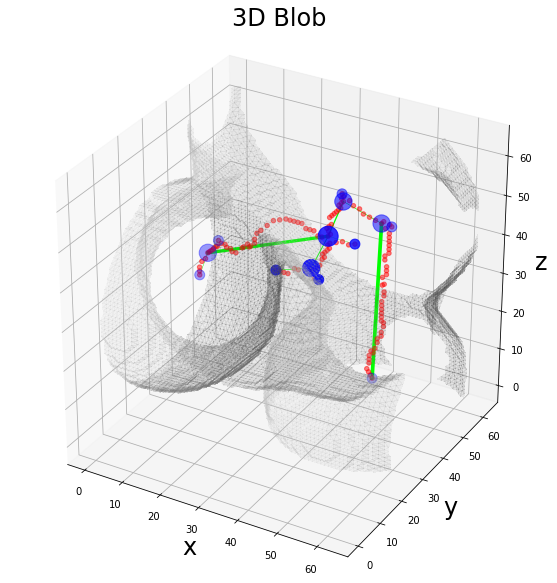

In [12]:
degree = nx.degree(graph)

# plot the results
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the skeleton shape
sx, sy, sz = np.where(np_skeleton)
ax.scatter(sz, sy, sx, color='r', marker='o', s=20, alpha=0.5)

# define the size of the nodes as 100x the degree value
degree_size = [degree[n]*100 for n in nodes]

# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=degree_size)
    
# plot the edges as lines between vertices
for ex, ey, w in wedges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=w/10)
    
# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.1,
                antialiased=False, 
                linewidth=0.0
               )
ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)))
ax.set_xlabel('x', fontsize=24)
ax.set_ylabel('y', fontsize=24)
ax.set_zlabel('z', fontsize=24)
_ = ax.set_title('3D Blob', fontsize=24)

As expected, the only edges with a "visible" linewidth are the longest ones.

Further analyses about the network topology can be performed as much as other kinds of weighing.